<a href="https://colab.research.google.com/github/DwiAyuniRohana/data-science-2025/blob/main/Pertemuan7_DwiAyuni_250401020173.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

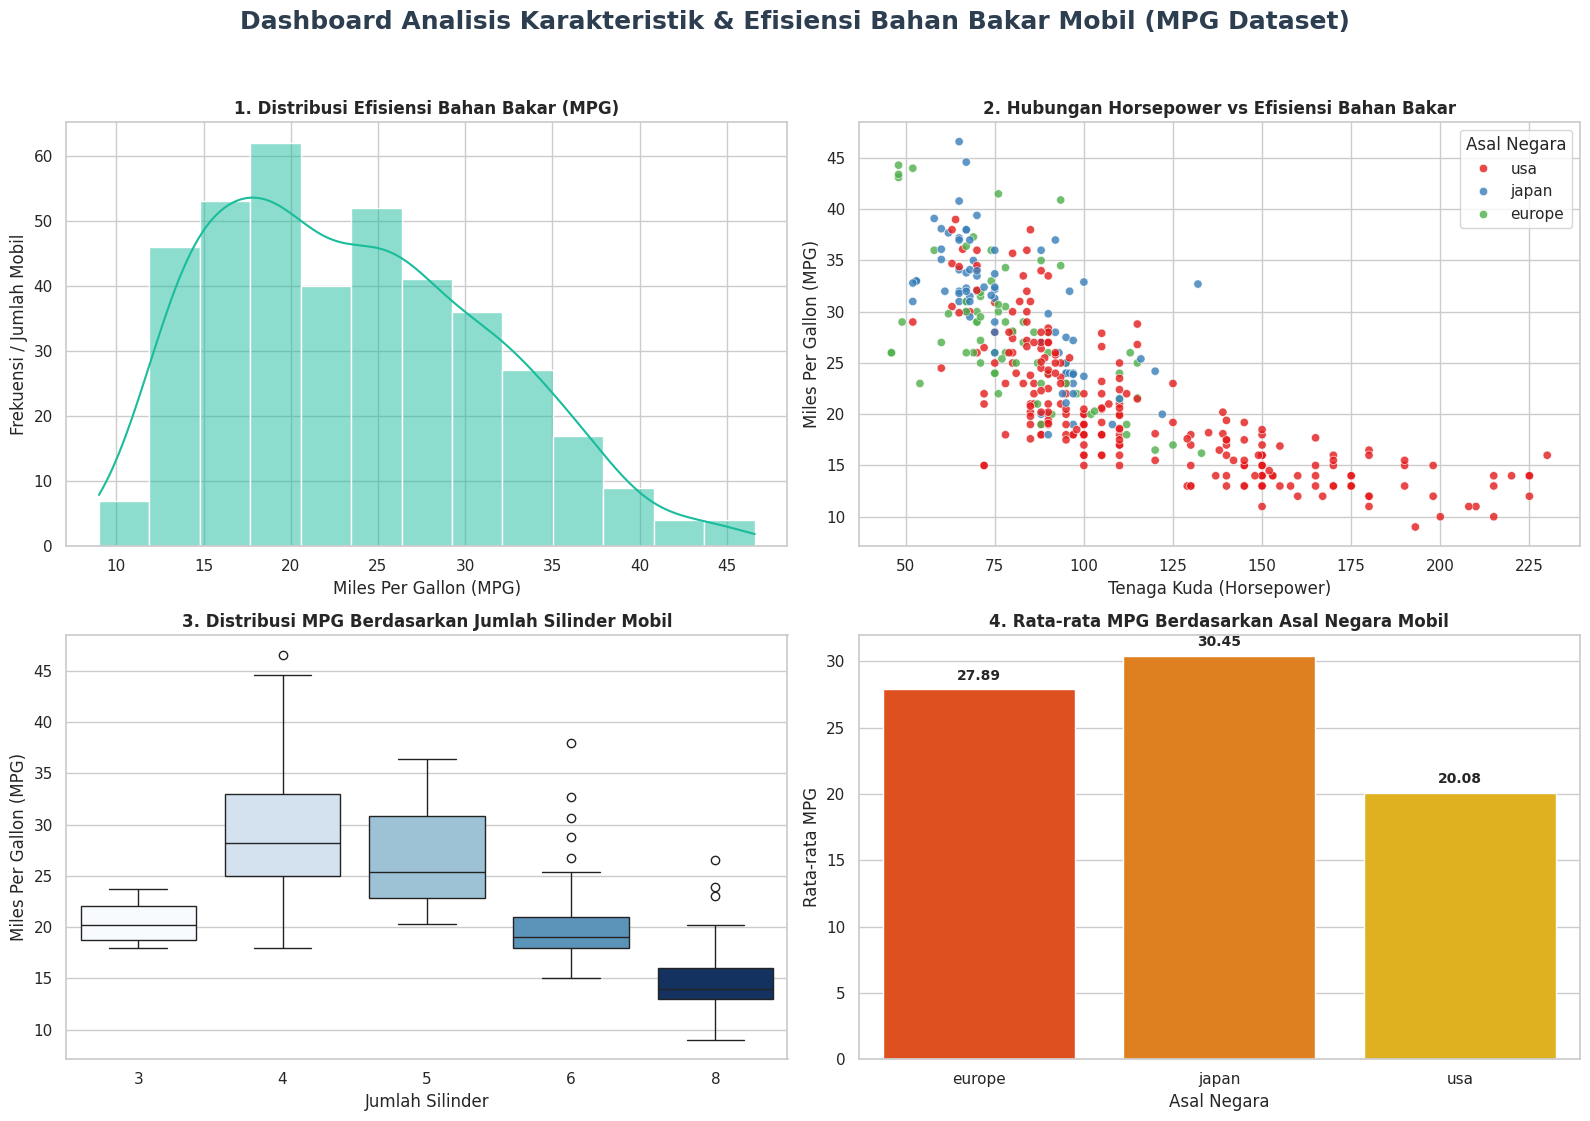

In [1]:
# ==============================================================================
# TUGAS BAB 6: DASHBOARD VISUALISASI STATIS UTUH
# Mata Kuliah: Pengantar Data Science - Pertemuan 7
# ==============================================================================

# LANGKAH 1: Mengimpor Library yang Diperlukan
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# LANGKAH 2: Mengatur Tema Dasar Visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# LANGKAH 3: Memuat Dataset
data_mpg = sns.load_dataset('mpg')

# Membersihkan missing value
data_mpg['horsepower'] = data_mpg['horsepower'].fillna(
    data_mpg['horsepower'].median()
)

# ==============================================================================
# LANGKAH 4: Inisialisasi Dashboard
# ==============================================================================
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))

fig.suptitle(
    'Dashboard Analisis Karakteristik & Efisiensi Bahan Bakar Mobil (MPG Dataset)',
    fontsize=18,
    fontweight='bold',
    y=0.96,
    color='#2c3e50'
)

# ------------------------------------------------------------------------------
# GRAFIK 1 : Histogram + KDE
# ------------------------------------------------------------------------------
sns.histplot(
    data=data_mpg,
    x='mpg',
    kde=True,
    color='#1abc9c',
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    '1. Distribusi Efisiensi Bahan Bakar (MPG)',
    fontsize=12,
    fontweight='bold'
)
axes[0, 0].set_xlabel('Miles Per Gallon (MPG)')
axes[0, 0].set_ylabel('Frekuensi / Jumlah Mobil')

# ------------------------------------------------------------------------------
# GRAFIK 2 : Scatter Plot
# ------------------------------------------------------------------------------
sns.scatterplot(
    data=data_mpg,
    x='horsepower',
    y='mpg',
    hue='origin',
    palette='Set1',
    alpha=0.8,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    '2. Hubungan Horsepower vs Efisiensi Bahan Bakar',
    fontsize=12,
    fontweight='bold'
)
axes[0, 1].set_xlabel('Tenaga Kuda (Horsepower)')
axes[0, 1].set_ylabel('Miles Per Gallon (MPG)')
axes[0, 1].legend(title='Asal Negara')

# ------------------------------------------------------------------------------
# GRAFIK 3 : Boxplot
# ------------------------------------------------------------------------------
sns.boxplot(
    data=data_mpg,
    x='cylinders',
    y='mpg',
    hue='cylinders',
    palette='Blues',
    legend=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    '3. Distribusi MPG Berdasarkan Jumlah Silinder Mobil',
    fontsize=12,
    fontweight='bold'
)
axes[1, 0].set_xlabel('Jumlah Silinder')
axes[1, 0].set_ylabel('Miles Per Gallon (MPG)')

# ------------------------------------------------------------------------------
# GRAFIK 4 : Barplot
# ------------------------------------------------------------------------------
avg_mpg_origin = (
    data_mpg
    .groupby('origin', as_index=False)['mpg']
    .mean()
)

sns.barplot(
    data=avg_mpg_origin,
    x='origin',
    y='mpg',
    hue='origin',
    palette='autumn',
    legend=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    '4. Rata-rata MPG Berdasarkan Asal Negara Mobil',
    fontsize=12,
    fontweight='bold'
)
axes[1, 1].set_xlabel('Asal Negara')
axes[1, 1].set_ylabel('Rata-rata MPG')

# Label nilai pada bar chart
for p in axes[1, 1].patches:
    height = p.get_height()

    axes[1, 1].annotate(
        f'{height:.2f}',
        (p.get_x() + p.get_width()/2, height),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

# ==============================================================================
# LANGKAH 5: Finalisasi Layout
# ==============================================================================
plt.tight_layout(rect=[0, 0.03, 1, 0.93])

plt.show()